# 1. Zadanie 1: Salud 2030

In [2]:
import time

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import(
    accuracy_score,
    recall_score,
    precision_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    make_scorer,
    confusion_matrix,
    roc_curve,
    auc,
)

## 1.1 EDA

In [3]:
df = pd.read_csv('./data/ObesityDataSet_raw_and_data_sinthetic.csv')
df.head(20)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [243]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


### Data cleaning

#### Brakujące wartości

In [244]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

Nie ma brakujących wartości.

#### Duplikaty

In [4]:
print("liczba duplikatów:")
print(df.duplicated().sum())
df[df.duplicated(keep=False)]

liczba duplikatów:
24


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
97,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
105,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
106,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
145,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
208,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight
209,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight


In [5]:
df = df.drop_duplicates()
df.info()

<class 'pandas.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2087 non-null   str    
 1   Age                             2087 non-null   float64
 2   Height                          2087 non-null   float64
 3   Weight                          2087 non-null   float64
 4   family_history_with_overweight  2087 non-null   str    
 5   FAVC                            2087 non-null   str    
 6   FCVC                            2087 non-null   float64
 7   NCP                             2087 non-null   float64
 8   CAEC                            2087 non-null   str    
 9   SMOKE                           2087 non-null   str    
 10  CH2O                            2087 non-null   float64
 11  SCC                             2087 non-null   str    
 12  FAF                             2087 non-null   fl

### Opis kolumn
| Nazwa kolumny | Opis | Rodzaj danych | Możliwe wartości / Zakres |
|---|---|---|---|
| `Gender` | Płeć | Kategoryczna | Kobieta, Mężczyzna |
| `Age` | Wiek | Numeryczna | Wartość numeryczna |
| `Height` | Wzrost | Numeryczna | Wartość numeryczna (w metrach) |
| `Weight` | Waga | Numeryczna | Wartość numeryczna (w kilogramach) |
| `family_history_with_overweight` | Czy członek rodziny cierpiał lub cierpi na nadwagę? | Kategoryczna (binarna) | Tak, Nie |
| `FAVC` | Czy często spożywasz jedzenie wysokokaloryczne? | Kategoryczna (binarna) | Tak, Nie |
| `FCVC` | Czy zazwyczaj jesz warzywa w swoich posiłkach? | Numeryczna | Nigdy, Czasami, Zawsze (zakodowane numerycznie) |
| `NCP` | Ile głównych posiłków jesz w ciągu dnia? | Numeryczna | Między 1 a 2, Trzy, Więcej niż trzy (zakodowane numerycznie) |
| `CAEC` | Czy jesz cokolwiek pomiędzy posiłkami? | Kategoryczna | Nie, Czasami, Często, Zawsze |
| `SMOKE` | Czy palisz papierosy? | Kategoryczna (binarna) | Tak, Nie |
| `CH2O` | Ile wody wypijasz dziennie? | Numeryczna | Mniej niż litr, Między 1 a 2 litry, Więcej niż 2 litry (zakodowane numerycznie) |
| `SCC` | Czy monitorujesz spożywane codziennie kalorie? | Kategoryczna (binarna) | Tak, Nie |
| `FAF` | Jak często podejmujesz aktywność fizyczną? | Numeryczna | Brak, 1 lub 2 dni, 2 do 4 dni, 4 lub 5 dni (zakodowane numerycznie) |
| `TUE` | Ile czasu spędzasz przed urządzeniami technologicznymi takimi jak telefon, gry wideo, telewizja, komputer i inne? | Numeryczna | 0–2 godziny, 3–5 godzin, Więcej niż 5 godzin (zakodowane numerycznie) |
| `CALC` | Jak często pijesz alkohol? | Kategoryczna | Nie piję, Czasami, Często, Zawsze |
| `MTRANS` | Jakiego środka transportu najczęściej używasz? | Kategoryczna | Samochód, Motocykl, Rower, Transport publiczny, Pieszo |
| `NObeyesdad` (kolumna z etykietą klasy) | Poziom otyłości | Kategoryczna | Niedowaga, Waga prawidłowa, Nadwaga I, Nadwaga II, Otyłość I, Otyłość II, Otyłość III |

Text(0.5, 1.0, 'Rozkład klas')

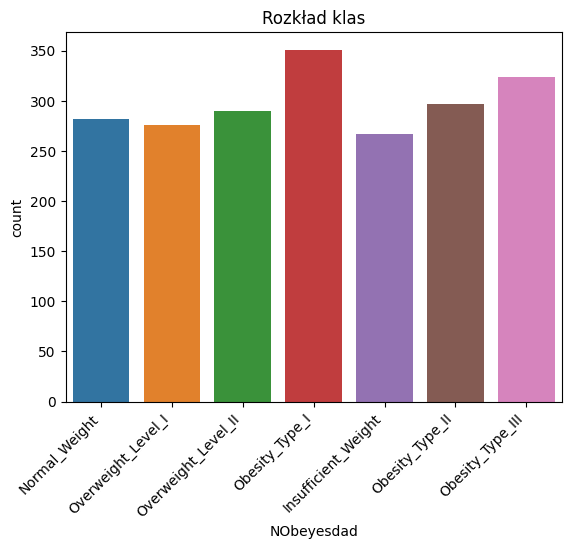

In [247]:
sns.countplot(df, x=df.NObeyesdad, hue='NObeyesdad')
plt.xticks(rotation=45, ha='right')
plt.title('Rozkład klas')

Dane są zrównoważone.

### Rozkład poszczególnych cech

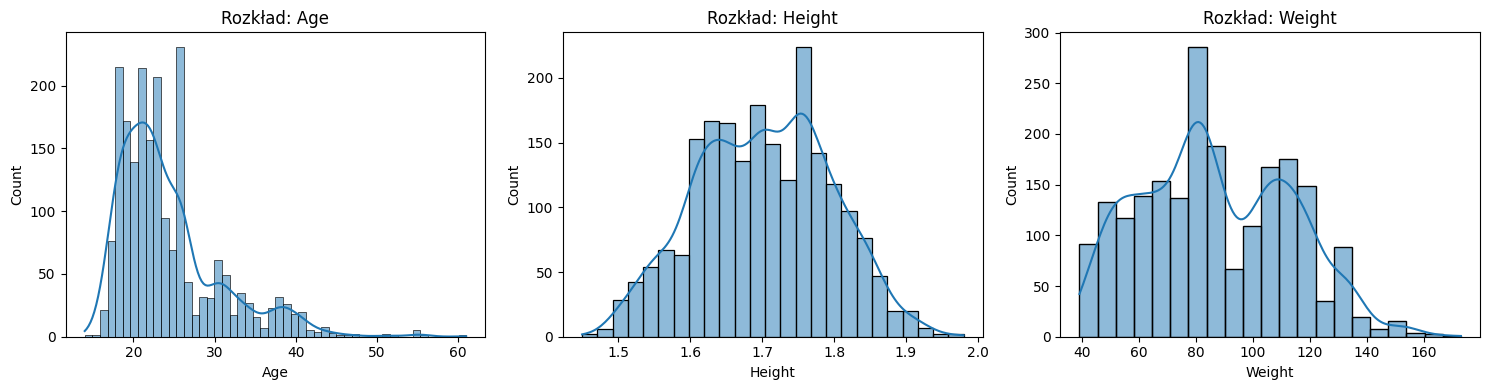

In [248]:
continuous_cols = ['Age', 'Height', 'Weight']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

for i, col in enumerate(continuous_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Rozkład: {col}')

plt.tight_layout()
plt.show()



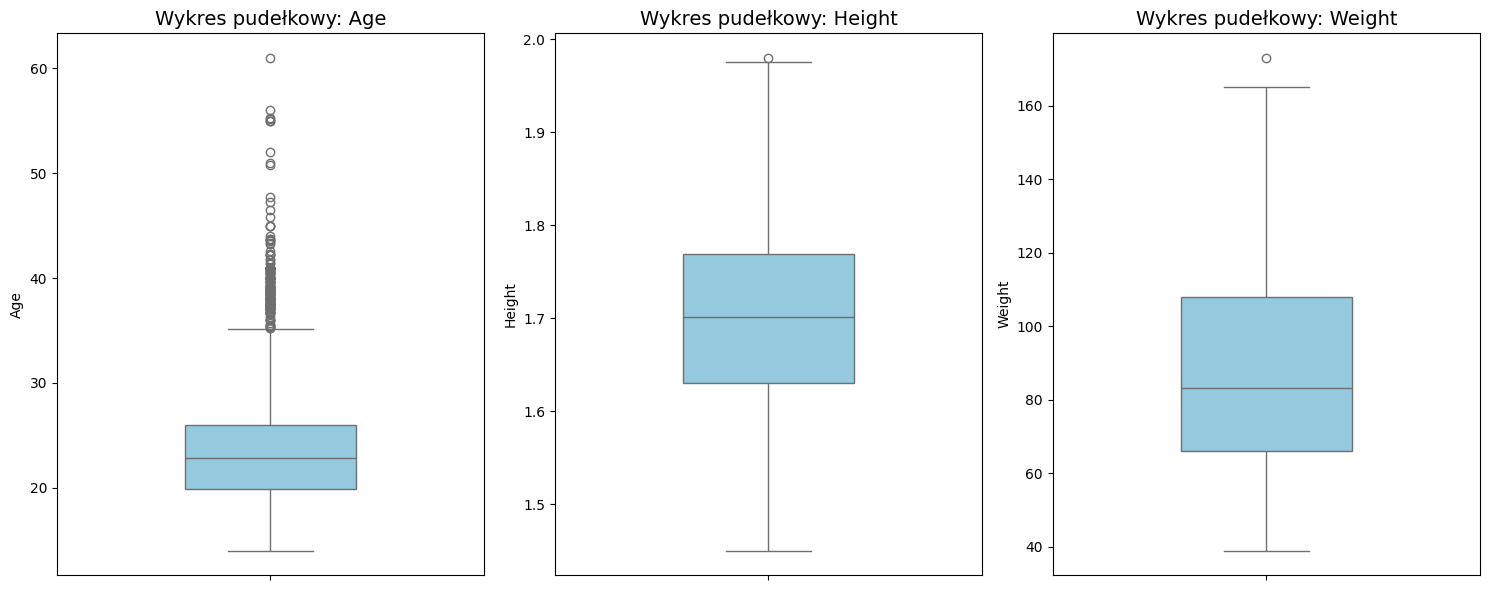

In [249]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

for i, col in enumerate(continuous_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue', width=0.4)
    
    axes[i].set_title(f'Wykres pudełkowy: {col}', fontsize=14)

plt.tight_layout()
plt.show()

Raczej czyste dane bez jakichś wymyślnych wartości, które mogłby być błędami.

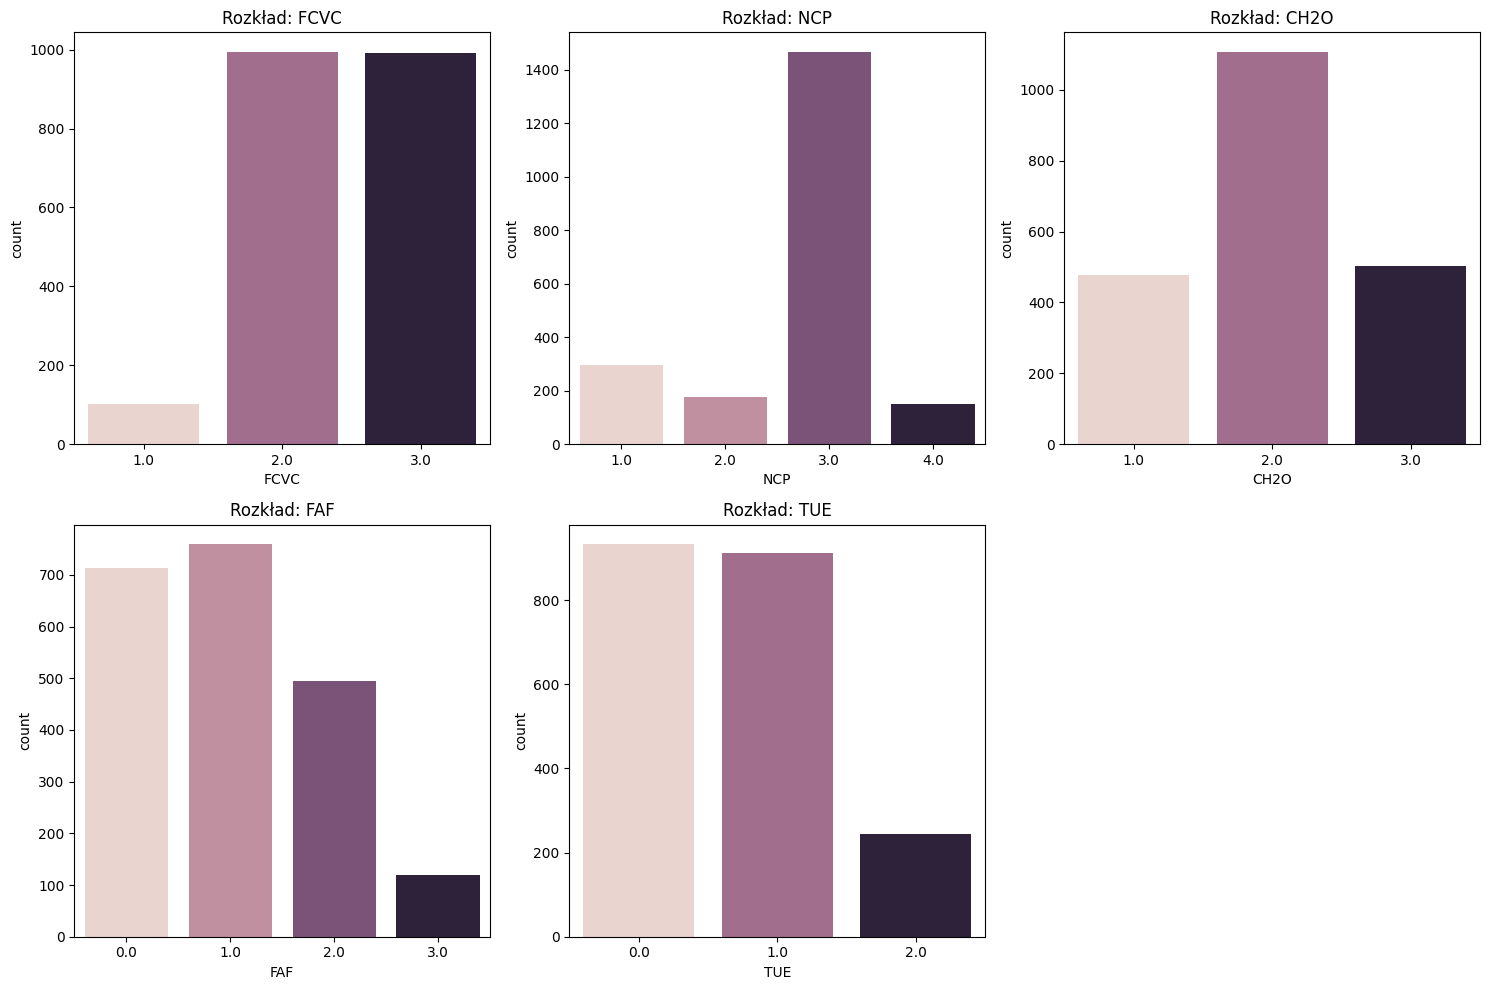

In [9]:
discrete_num_cols = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(discrete_num_cols):
    rounded_data = df[col].round()
    
    sns.countplot(x=rounded_data, ax=axes[i], hue=rounded_data, legend=False)
    axes[i].set_title(f'Rozkład: {col}')
    
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

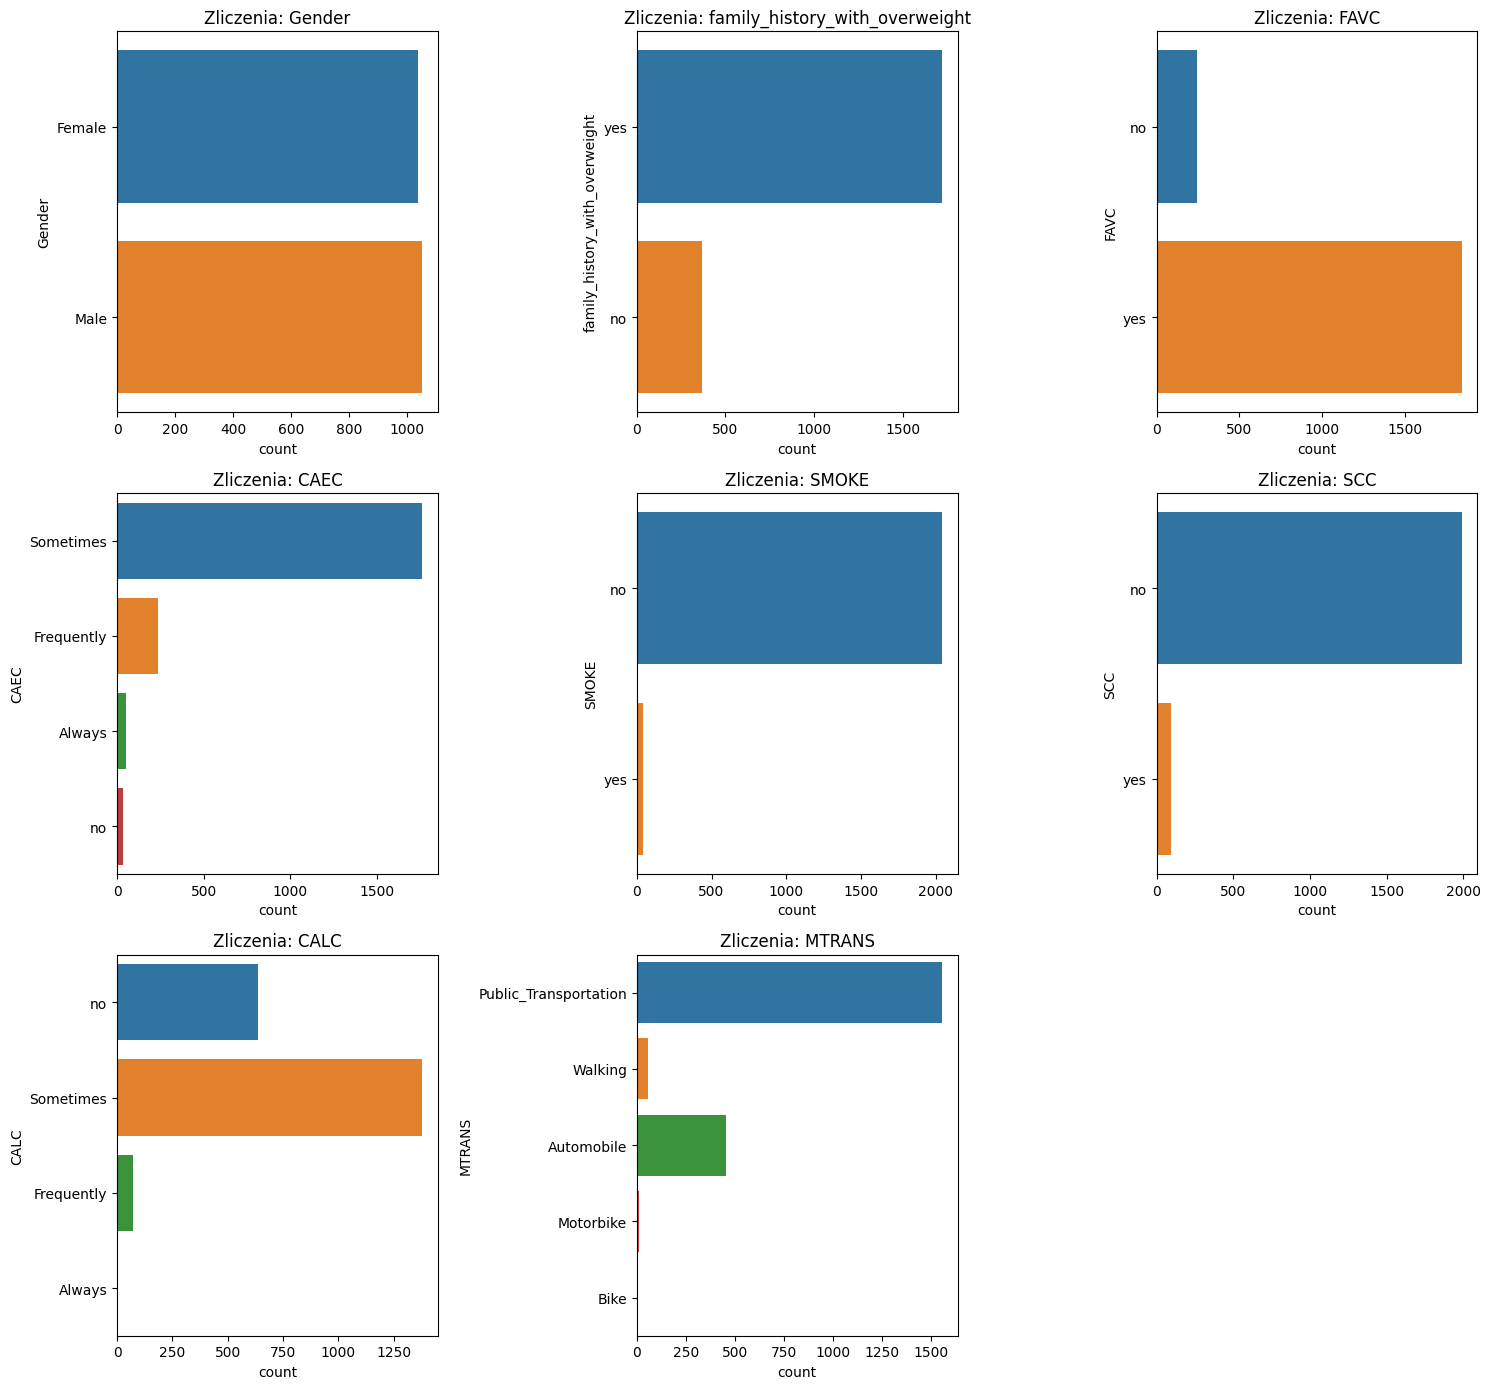

In [11]:
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, y=col, ax=axes[i], hue=col, legend=False)
    axes[i].set_title(f'Zliczenia: {col}')

    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

#### Macierz korelacji

In [6]:
df_encoded = df.copy()

obesity_mapping = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}
df_encoded['NObeyesdad'] = df_encoded['NObeyesdad'].map(obesity_mapping)

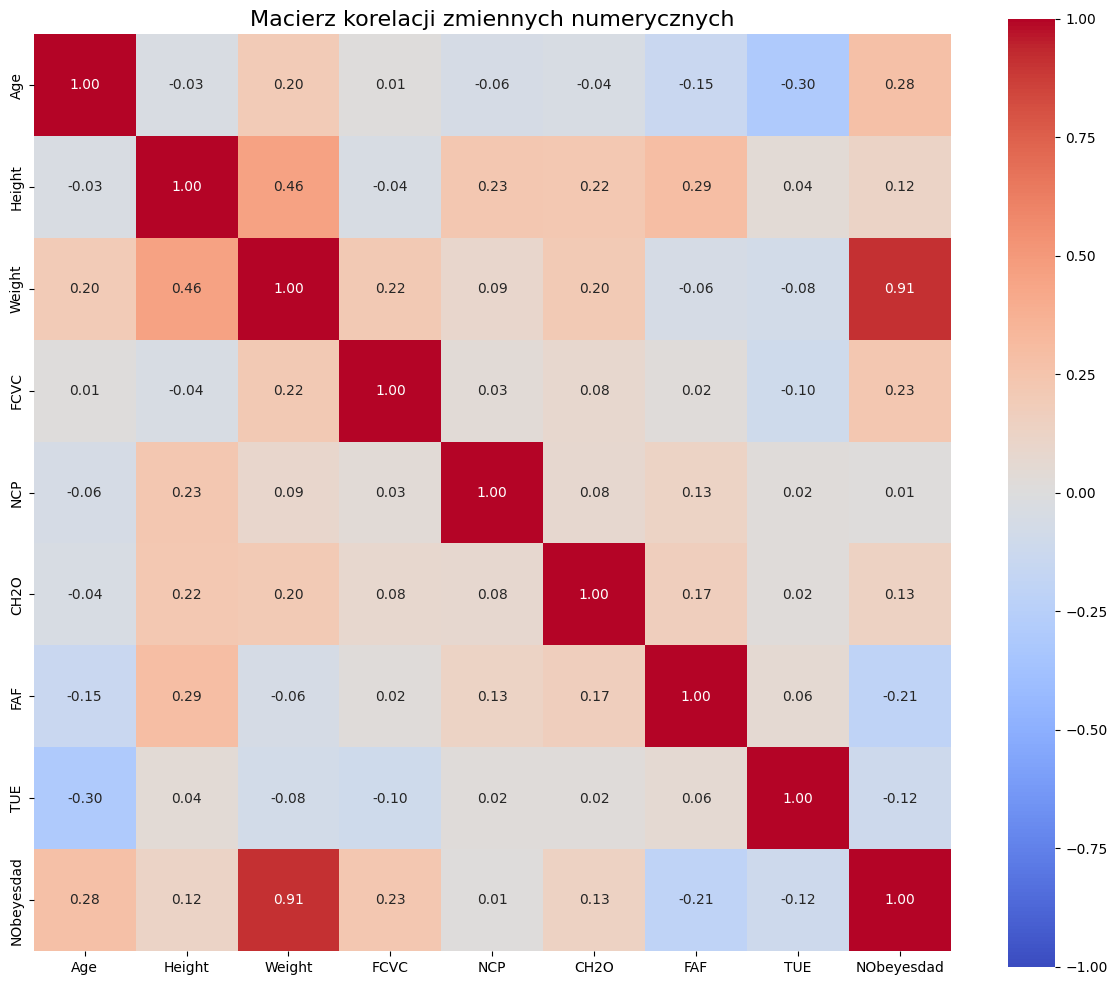

In [7]:
numeric_df = df_encoded.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, center=0, square=True)

plt.title('Macierz korelacji zmiennych numerycznych', fontsize=16)
plt.tight_layout()
plt.show()

Nie ma jakichś silnie skorelowanych danych wśród zmiennych numerycznych.

### Przekształcanie danych 

In [12]:
for col in discrete_num_cols:
    df_encoded[col] = df_encoded[col].round()

df_encoded = pd.get_dummies(df_encoded, columns=cat_cols, drop_first=True)

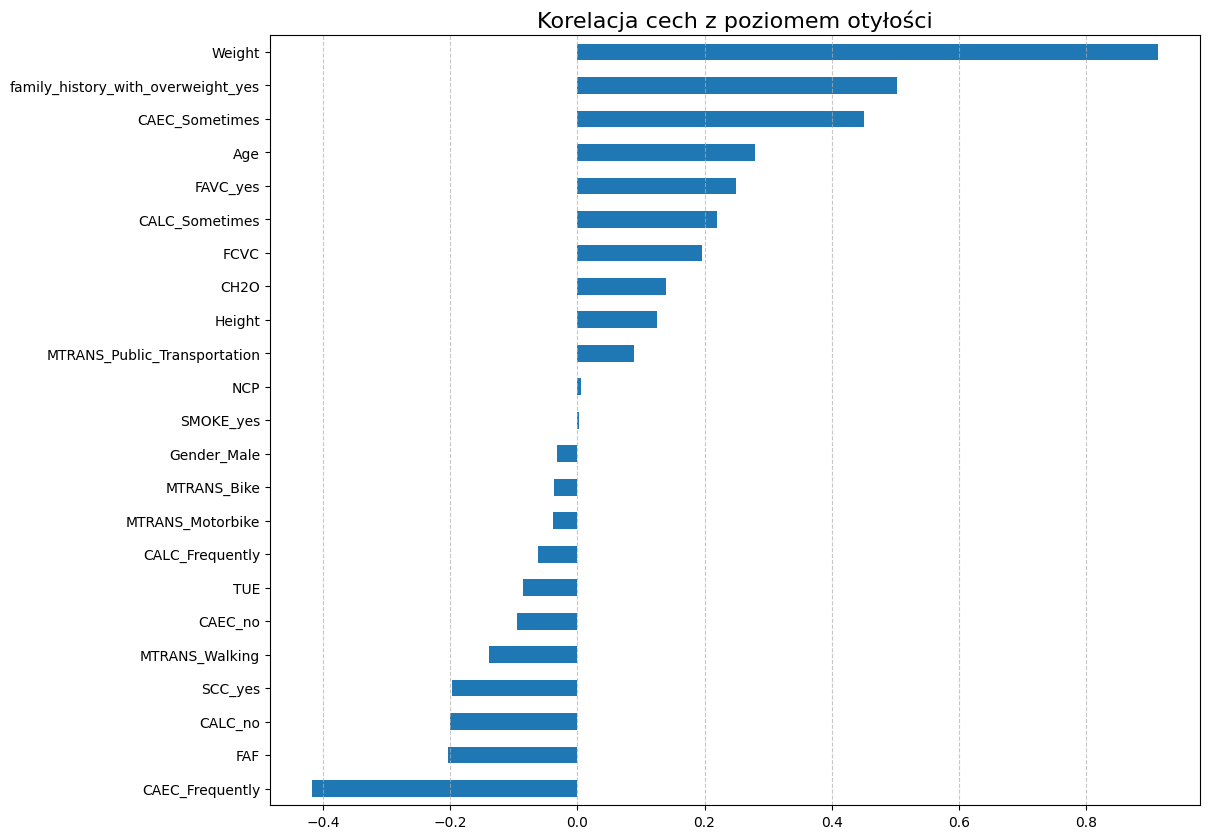

In [13]:
correlations = df_encoded.corr()['NObeyesdad'].drop('NObeyesdad').sort_values()

plt.figure(figsize=(12, 10))

correlations.plot(kind='barh')

plt.title('Korelacja cech z poziomem otyłości', fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Podział danych

In [255]:
X = df_encoded.drop(columns=['NObeyesdad']).copy()
y = df['NObeyesdad'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 1.2 Trenowanie modeli

In [256]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Drzewo decyzyjne

In [257]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

tree_cv_accuracy = cross_val_score(tree_model, X_train, y_train, cv=cv, scoring='accuracy')
print(f"Decision Tree: średnia dokładność na krzyżowej walidacji = {tree_cv_accuracy.mean():.4f}")
tree_cv_recall_m = cross_val_score(tree_model, X_train, y_train, cv=cv, scoring='recall_macro')
print(f"Decision Tree: średnia czułość macro na krzyżowej walidacji = {tree_cv_recall_m.mean():.4f}")
tree_cv_recall_w = cross_val_score(tree_model, X_train, y_train, cv=cv, scoring='recall_weighted')
print(f"Decision Tree: średnia czułość ważona na krzyżowej walidacji = {tree_cv_recall_w.mean():.4f}")

Decision Tree: średnia dokładność na krzyżowej walidacji = 0.8251
Decision Tree: średnia czułość macro na krzyżowej walidacji = 0.8167
Decision Tree: średnia czułość ważona na krzyżowej walidacji = 0.8251


In [258]:
tree_model.fit(X_train, y_train)
times = []
for _ in range(100):
    start_time = time.perf_counter()
    tree_preds = tree_model.predict(X_test)
    end_time = time.perf_counter()
    times.append(end_time-start_time)
tree_prediction_time = sum(times) / len(times)
print(f"Średni czas predykcji drzewa: {tree_prediction_time:.6f} s")

Średni czas predykcji drzewa: 0.000102 s


In [259]:
print(classification_report(y_test, tree_preds))

                     precision    recall  f1-score   support

Insufficient_Weight       0.95      0.98      0.96        53
      Normal_Weight       0.93      0.65      0.76        57
     Obesity_Type_I       0.76      0.96      0.85        70
    Obesity_Type_II       0.98      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.71      0.53      0.60        55
Overweight_Level_II       0.56      0.69      0.62        58

           accuracy                           0.83       418
          macro avg       0.84      0.82      0.82       418
       weighted avg       0.84      0.83      0.83       418



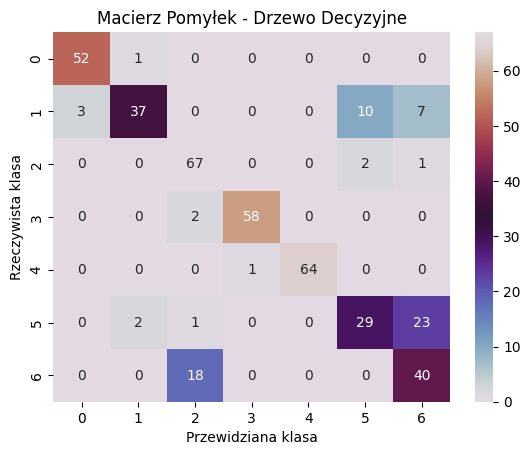

In [260]:
sns.heatmap(confusion_matrix(y_test, tree_preds), annot=True, fmt='d', cmap='twilight')
plt.title('Macierz Pomyłek - Drzewo Decyzyjne')
plt.xlabel('Przewidziana klasa')
plt.ylabel('Rzeczywista klasa')
plt.show()

### Regresja logistyczna

In [261]:
logreg_model = LogisticRegression(max_iter=10000, random_state=42)

logreg_cv_accuracy = cross_val_score(tree_model, X_train, y_train, cv=cv, scoring='accuracy')
print(f"Decision Tree: średnia dokładność na krzyżowej walidacji = {logreg_cv_accuracy.mean():.4f}")
logreg_cv_recall_m = cross_val_score(tree_model, X_train, y_train, cv=cv, scoring='recall_macro')
print(f"Decision Tree: średnia czułość macro na krzyżowej walidacji = {logreg_cv_recall_m.mean():.4f}")
logreg_cv_recall_w = cross_val_score(tree_model, X_train, y_train, cv=cv, scoring='recall_weighted')
print(f"Decision Tree: średnia czułość ważona na krzyżowej walidacji = {logreg_cv_recall_w.mean():.4f}")

Decision Tree: średnia dokładność na krzyżowej walidacji = 0.8251


Decision Tree: średnia czułość macro na krzyżowej walidacji = 0.8167
Decision Tree: średnia czułość ważona na krzyżowej walidacji = 0.8251


In [262]:
logreg_model.fit(X_train, y_train)

times = []
for _ in range(100):
    start_time = time.perf_counter()
    logreg_preds = logreg_model.predict(X_test)
    end_time = time.perf_counter()
    times.append(end_time-start_time)
logreg_prediction_time = sum(times) / len(times)
print(f"Czas predykcji regresji logistycznej: {logreg_prediction_time:.6f} s")

Czas predykcji regresji logistycznej: 0.000165 s


In [263]:
print(classification_report(y_test, logreg_preds))

                     precision    recall  f1-score   support

Insufficient_Weight       0.93      1.00      0.96        53
      Normal_Weight       0.84      0.81      0.82        57
     Obesity_Type_I       0.90      0.91      0.91        70
    Obesity_Type_II       0.94      0.98      0.96        60
   Obesity_Type_III       0.98      0.98      0.98        65
 Overweight_Level_I       0.79      0.82      0.80        55
Overweight_Level_II       0.84      0.72      0.78        58

           accuracy                           0.89       418
          macro avg       0.89      0.89      0.89       418
       weighted avg       0.89      0.89      0.89       418



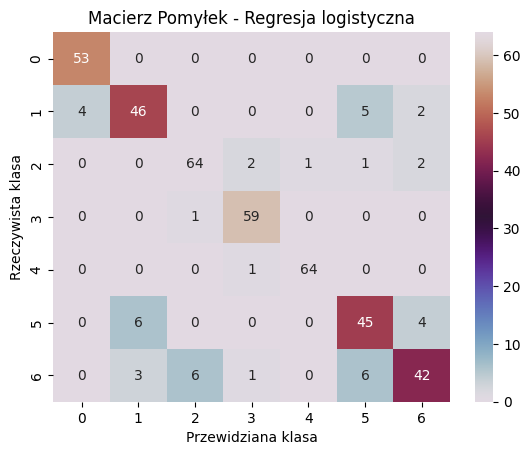

In [264]:
sns.heatmap(confusion_matrix(y_test, logreg_preds), annot=True, fmt='d', cmap='twilight')
plt.title('Macierz Pomyłek - Regresja logistyczna')
plt.xlabel('Przewidziana klasa')
plt.ylabel('Rzeczywista klasa')
plt.show()

### Bagging

In [265]:
base_shallow_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
base_deep_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
base_logreg = LogisticRegression(max_iter=1000, random_state=42)

param_grid = {
    'estimator': [base_shallow_tree, base_deep_tree, base_logreg],
    'n_estimators': [10, 25, 50, 100],
    'bootstrap': [True, False],
    'bootstrap_features': [False, True]
}

scoring_metrics = {
    'Accuracy': 'accuracy',
    'Precision': 'precision_macro',
    'Recall': 'recall_macro',
    'F2': make_scorer(fbeta_score, beta=2, average='macro')
}

base_bagging = BaggingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=base_bagging,
    param_grid=param_grid,
    scoring=scoring_metrics,
    refit='Recall',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BaggingClassi...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'bootstrap_features': [False, True], 'estimator': [DecisionTreeC...ndom_state=42), DecisionTreeC...ndom_state=42), ...], 'n_estimators': [10, 25, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'Accuracy': 'accuracy', 'F2': make_scorer(f...average=macro), 'Precision': 'precision_macro', 'Recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'Recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default 

In [266]:
best_bagging_model = grid_search.best_estimator_

start_time = time.perf_counter()
predictions_bagging = best_bagging_model.predict(X_test)
end_time = time.perf_counter()


print('NAJLEPSZY ZBIÓR KLASYFIKATORÓW:')
print(f'params: {grid_search.best_params_}')
print(f'score: {grid_search.best_score_}')
print(f'time: {end_time-start_time} s')

NAJLEPSZY ZBIÓR KLASYFIKATORÓW:
params: {'bootstrap': True, 'bootstrap_features': True, 'estimator': DecisionTreeClassifier(random_state=42), 'n_estimators': 100}
score: 0.9578019160727408
time: 0.012062620997312479 s


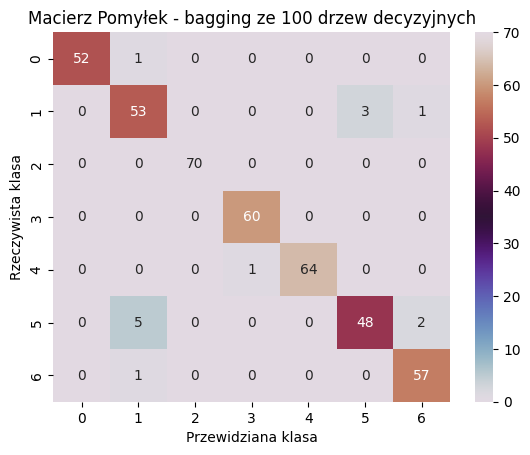

In [267]:
sns.heatmap(confusion_matrix(y_test, predictions_bagging), annot=True, fmt='d', cmap='twilight')
plt.title('Macierz Pomyłek - bagging ze 100 drzew decyzyjnych')
plt.xlabel('Przewidziana klasa')
plt.ylabel('Rzeczywista klasa')
plt.show()

### ADA Boost

In [268]:
ada_param_grid = {
    'estimator': [base_shallow_tree, base_logreg],
    'n_estimators': [10, 25, 50, 100],
    'learning_rate': [0.01, 0.2, 0.5, 1.0]
}

ada_grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=ada_param_grid,
    scoring=scoring_metrics,
    refit='Recall',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

ada_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator': [DecisionTreeC...ndom_state=42), LogisticRegre...ndom_state=42)], 'learning_rate': [0.01, 0.2, ...], 'n_estimators': [10, 25, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'Accuracy': 'accuracy', 'F2': make_scorer(f...average=macro), 'Precision': 'precision_macro', 'Recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'Recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold t

In [269]:
best_ada_model = ada_grid_search.best_estimator_

start_time = time.perf_counter()
pred_ada = best_ada_model.predict(X_test)
end_time = time.perf_counter()


print('NAJLEPSZY ZBIÓR KLASYFIKATORÓW:')
print(f'params: {ada_grid_search.best_params_}')
print(f'score: {ada_grid_search.best_score_}')
print(f'time: {end_time-start_time} s')

NAJLEPSZY ZBIÓR KLASYFIKATORÓW:
params: {'estimator': DecisionTreeClassifier(max_depth=4, random_state=42), 'learning_rate': 1.0, 'n_estimators': 100}
score: 0.9595606944621512
time: 0.016353580002032686 s


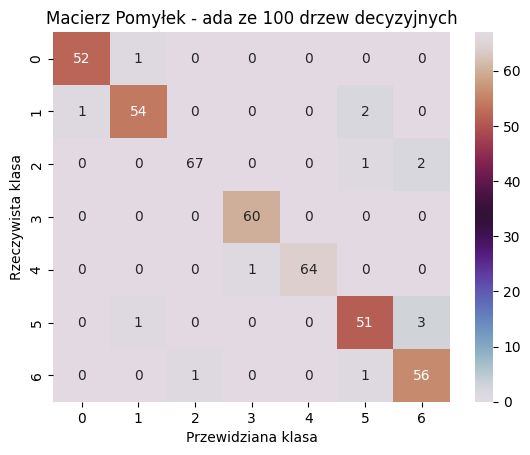

In [270]:
sns.heatmap(confusion_matrix(y_test, pred_ada), annot=True, fmt='d', cmap='twilight')
plt.title('Macierz Pomyłek - ada ze 100 drzew decyzyjnych')
plt.xlabel('Przewidziana klasa')
plt.ylabel('Rzeczywista klasa')
plt.show()

### Gradient Boosting

In [271]:
gb_param_grid = {
    'n_estimators': [50, 100, 250, 500],
    'learning_rate': [0.01, 0.2, 0.5, 1.0]
}

gb_grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    scoring=scoring_metrics,
    refit='Recall',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gb_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.2, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'Accuracy': 'accuracy', 'F2': make_scorer(f...average=macro), 'Precision': 'precision_macro', 'Recall': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'Recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the v

In [272]:
best_gb_model = gb_grid_search.best_estimator_

start_time = time.perf_counter()
pred_gb = best_gb_model.predict(X_test)
end_time = time.perf_counter()


print('NAJLEPSZY ZBIÓR KLASYFIKATORÓW:')
print(f'params: {gb_grid_search.best_params_}')
print(f'score: {gb_grid_search.best_score_}')
print(f'time: {end_time-start_time} s')

NAJLEPSZY ZBIÓR KLASYFIKATORÓW:
params: {'learning_rate': 0.2, 'n_estimators': 250}
score: 0.959552342071461
time: 0.010913953999988735 s


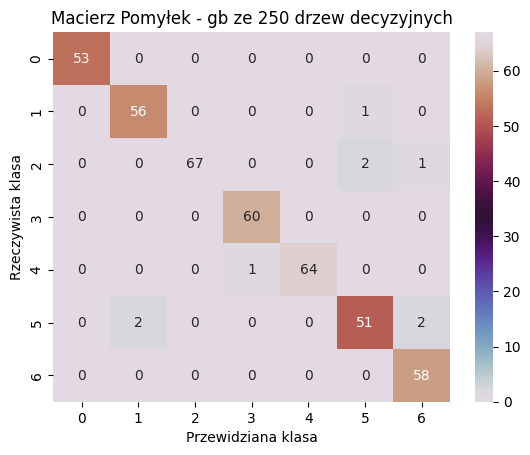

In [273]:
sns.heatmap(confusion_matrix(y_test, pred_gb), annot=True, fmt='d', cmap='twilight')
plt.title('Macierz Pomyłek - gb ze 250 drzew decyzyjnych')
plt.xlabel('Przewidziana klasa')
plt.ylabel('Rzeczywista klasa')
plt.show()

### Voting

In [274]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
knn = KNeighborsClassifier(n_neighbors=7)

voting_clf_soft = VotingClassifier(
    estimators=[('DTree', tree_model), ('LogRef', logreg_model), ('SVM', svm), ('KNN', knn)], 
    voting='soft',
    n_jobs=-1
)

voting_clf_hard = VotingClassifier(
    estimators=[('DTree', tree_model), ('LogRef', logreg_model), ('SVM', svm), ('KNN', knn)], 
    voting='hard',
    n_jobs=-1
)
voting_clf_soft.fit(X_train, y_train)
voting_clf_hard.fit(X_train, y_train)


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('DTree', ...), ('LogRef', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [275]:
start_time = time.perf_counter()
pred_voting_soft = voting_clf_soft.predict(X_test)
end_time = time.perf_counter()


print('WYNIKI SOFT VOTING:')
voting_soft_recall = recall_score(y_test, pred_voting_soft, average='macro')
print(f'recall score: {voting_soft_recall}')
print(f'time: {end_time-start_time} s')

WYNIKI SOFT VOTING:
recall score: 0.8888426628250325
time: 0.022562399004527833 s


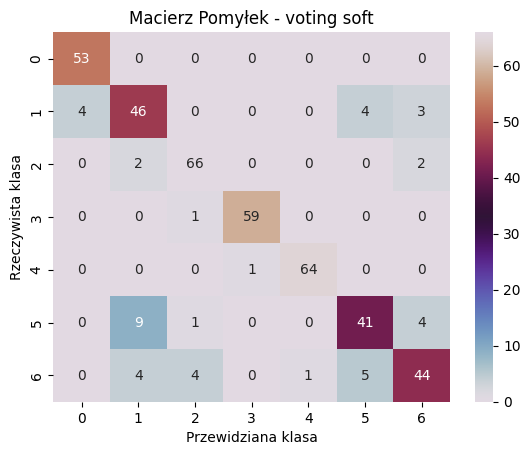

In [276]:
sns.heatmap(confusion_matrix(y_test, pred_voting_soft), annot=True, fmt='d', cmap='twilight')
plt.title('Macierz Pomyłek - voting soft')
plt.xlabel('Przewidziana klasa')
plt.ylabel('Rzeczywista klasa')
plt.show()

In [277]:
start_time = time.perf_counter()
pred_voting_hard = voting_clf_hard.predict(X_test)
end_time = time.perf_counter()


print('WYNIKI HARD VOTING:')
voting_hard_recall = recall_score(y_test, pred_voting_hard, average='macro')
print(f'recall score: {voting_hard_recall}')
print(f'time: {end_time-start_time} s')

WYNIKI HARD VOTING:
recall score: 0.8763652085534378
time: 0.02451095899596112 s


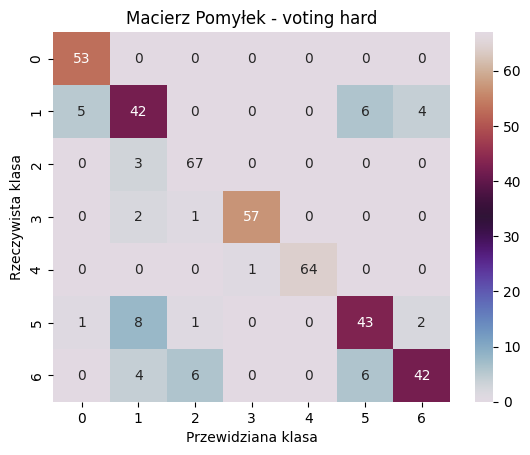

In [278]:
sns.heatmap(confusion_matrix(y_test, pred_voting_hard), annot=True, fmt='d', cmap='twilight')
plt.title('Macierz Pomyłek - voting hard')
plt.xlabel('Przewidziana klasa')
plt.ylabel('Rzeczywista klasa')
plt.show()

## 1.3 Ostateczna walidacja

In [ ]:
models = {
    "Drzewo": tree_model,
    "Regresja Logistyczna": logreg_model,
    "Bagging": best_bagging_model,
    "AdaBoost": best_ada_model,
    "Gradient Boosting": best_gb_model,
    "Voting Classifier - soft": voting_clf_soft,
    "Voting Classifier - hard": voting_clf_hard
}

results = []

for name, model in models.items():
    start_time = time.perf_counter()
    preds = model.predict(X_test)
    pred_time = time.perf_counter() - start_time
    
    acc = accuracy_score(y_test, preds)
    recall = recall_score(y_test, preds, average='macro')
    if model is not voting_clf_hard:
        probs = model.predict_proba(X_test)
        confidence = np.max(probs, axis=1)
        avg_confidence = np.mean(confidence)
    else:
        avg_confidence = None

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Recall (Macro)": recall,
        "Średnia Pewność": avg_confidence,
        "Czas predykcji [s]": pred_time
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Recall (Macro)", ascending=False)


results_df

,Model,Accuracy,Recall (Macro),Średnia Pewność,Czas predykcji [s]
4,Gradient Boosting,0.978469,0.978784,0.991041,0.008393
3,AdaBoost,0.966507,0.966150,0.152880,0.014227
2,Bagging,0.966507,0.964437,0.790164,0.010234
1,Regresja Logistyczna,0.892344,0.890225,0.765288,0.000120
5,Voting Classifier - soft,0.892344,0.888843,0.771436,0.020327
6,Voting Classifier - hard,0.880383,0.876365,NaN,0.059816
0,Drzewo,0.830144,0.822230,0.838694,0.000479


### Wnioski
Najlepszym modelem do realizacji założonego planu będzie Gradient Boosting, w tym wypadku składający się z 250 drzew decyzyjnych o głebokości 3. Nie dość, że jego wynik recall = 0.97 (nie chcemy nie diagnozować zagrozonych pacjentów) deklasuje pozostałe modele, to jeszcze robi to z wielką pewnością swoich decyzji - 0.99 - nie są to strzały. Wytrenowanie tego modelu nie należy do najszybyszch, ale za to korzsytanie z niego nie sprawia już problemu starszym sprzętym, gdyż sprowadza się to do zbioru ifów. Oprócz tego to rozwiązanie jest w pełni wytłumaczalne.